In [1]:
import cftime
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
import cartopy.feature as feature
import matplotlib.colors as colors
from cartopy.util import add_cyclic_point
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter)

from scipy import stats

In [2]:
# --- read mask

# input mask - Miocene
ds_mask = xr.open_dataset('../Miocene_LANDFRAC.nc')
var = 'LANDFRAC'
map_Mio = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Mio, lons = add_cyclic_point(map_Mio, coord=ds_mask['lon'])

# ==================================================================
# input mask - Preindustrial
ds_mask = xr.open_dataset('../Preindustrial_LANDFRAC.nc')
var = 'LANDFRAC'
map_Pi = ds_mask[var][0,:,:]
# Add cyclic point to mask
mask_Pi, lons = add_cyclic_point(map_Pi, coord=ds_mask['lon'])

In [3]:
lat = ds_mask['lat']
lon = ds_mask['lon']
weights = np.cos(np.deg2rad(lat))

## Regional Lambda:
### Regional Climate Feedback Parameter (Lambda to Miocene Dust Forcing) derived from annual-mean TS & TOA anomalies


In [6]:
# --- read data --- 

ds_lambda = xr.open_dataset('./FigS5_Regional_Lambda.nc')

lambda_Pi_first30 = ds_lambda['FCM_Pi_LambdaR_first30']
lambda_Mio_first30 = ds_lambda['FCM_Mio_LambdaR_first30']
lambda_Pi_after50 = ds_lambda['FCM_Pi_LambdaR_after50']
lambda_Mio_after50 = ds_lambda['FCM_Mio_LambdaR_after50']

In [8]:
pattern_lambda = np.empty((4, lat.size, lon.size))
pattern_lambda = xr.DataArray(data=pattern_lambda, dims=['pattern','lat','lon'], coords=[np.arange(1,4.5,1), lat, lon])
pattern_lambda[0,:,:] = lambda_Pi_first30
pattern_lambda[1,:,:] = lambda_Mio_first30
pattern_lambda[2,:,:] = lambda_Pi_after50
pattern_lambda[3,:,:] = lambda_Mio_after50

pattern_lambda

<xarray.DataArray (pattern: 4, lat: 96, lon: 144)>
array([[[-4.29917037e-01, -4.50308621e-01, -4.28850800e-01, ...,
         -4.25510824e-01, -4.24630523e-01, -4.35395092e-01],
        [-1.97048807e+00, -1.96511328e+00, -1.95916879e+00, ...,
         -1.91180921e+00, -1.95439899e+00, -1.95705581e+00],
        [-3.75993657e+00, -3.98500252e+00, -3.95339274e+00, ...,
         -3.64786410e+00, -3.81828594e+00, -3.92262197e+00],
        ...,
        [ 1.32976303e+01,  1.37231026e+01,  1.41613970e+01, ...,
          1.27869158e+01,  1.28209467e+01,  1.29615355e+01],
        [ 1.16660357e+01,  1.20951862e+01,  1.24964228e+01, ...,
          1.04776897e+01,  1.08390045e+01,  1.12135324e+01],
        [ 1.27784529e+01,  1.28895149e+01,  1.30425348e+01, ...,
          1.25317354e+01,  1.25972481e+01,  1.26807175e+01]],

       [[-5.67023218e-01, -5.67743003e-01, -5.82630813e-01, ...,
         -5.95110714e-01, -5.91115594e-01, -9.15679574e-01],
        [-1.79481947e+00, -2.92086530e+00, -3.24535179e+00, ...,
         -3.42991495e+00, -2.52752066e+00, -1.79223686e-01],
        [ 1.37293130e-01,  6.74064234e-02,  6.66812837e-01, ...,
          2.06084466e+00, -6.62831068e-02, -1.74392068e+00],
...
        [ 7.31547594e+00,  7.33799791e+00,  7.32350254e+00, ...,
          7.27857971e+00,  7.30072498e+00,  7.30201674e+00],
        [ 9.14407158e+00,  9.12612629e+00,  9.11842918e+00, ...,
          9.20588493e+00,  9.18598652e+00,  9.17484665e+00],
        [ 1.01073046e+01,  1.01191664e+01,  1.01282778e+01, ...,
          1.01098232e+01,  1.01014690e+01,  1.00980835e+01]],

       [[-4.46188784e+00, -4.46001387e+00, -4.21716785e+00, ...,
         -4.29669046e+00, -4.60370064e+00, -4.29807186e+00],
        [-2.22921133e+00, -2.93658304e+00, -3.76104641e+00, ...,
         -3.02533340e+00, -2.84404731e+00, -2.98155594e+00],
        [-2.84554434e+00, -1.93805361e+00, -2.29174471e+00, ...,
         -1.87965548e+00, -2.68775105e+00, -1.95517981e+00],
        ...,
        [-9.10286754e-02, -6.89408779e-02,  1.06028339e-04, ...,
          4.33416432e-03, -2.76999492e-02, -1.08480051e-01],
        [-1.51796162e-01, -9.52157602e-02, -3.96716632e-02, ...,
         -3.05590451e-01, -2.48902828e-01, -1.99028671e-01],
        [ 9.41604152e-02,  8.95805508e-02,  8.54898244e-02, ...,
          8.82249773e-02,  8.89193341e-02,  8.98317620e-02]]])
Coordinates:
  * pattern  (pattern) float64 1.0 2.0 3.0 4.0
  * lat      (lat) float64 -90.0 -88.11 -86.21 -84.32 ... 84.32 86.21 88.11 90.0
  * lon      (lon) float64 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5

In [9]:
# Add cyclic point to data
data = pattern_lambda
data, lons = add_cyclic_point(data, coord=lon)

In [10]:
lambda_Pi_first30_mean = lambda_Pi_first30.weighted(weights).mean(dim=['lon','lat']) 
lambda_Mio_first30_mean = lambda_Mio_first30.weighted(weights).mean(dim=['lon','lat']) 
lambda_Pi_after50_mean = lambda_Pi_after50.weighted(weights).mean(dim=['lon','lat']) 
lambda_Mio_after50_mean = lambda_Mio_after50.weighted(weights).mean(dim=['lon','lat']) 

print('{:03.3f}'.format(lambda_Pi_first30_mean.values))
print('{:03.3f}'.format(lambda_Mio_first30_mean.values))
print('{:03.3f}'.format(lambda_Pi_after50_mean.values))
print('{:03.3f}'.format(lambda_Mio_after50_mean.values))

-1.493
-0.563
-1.270
-0.765


''

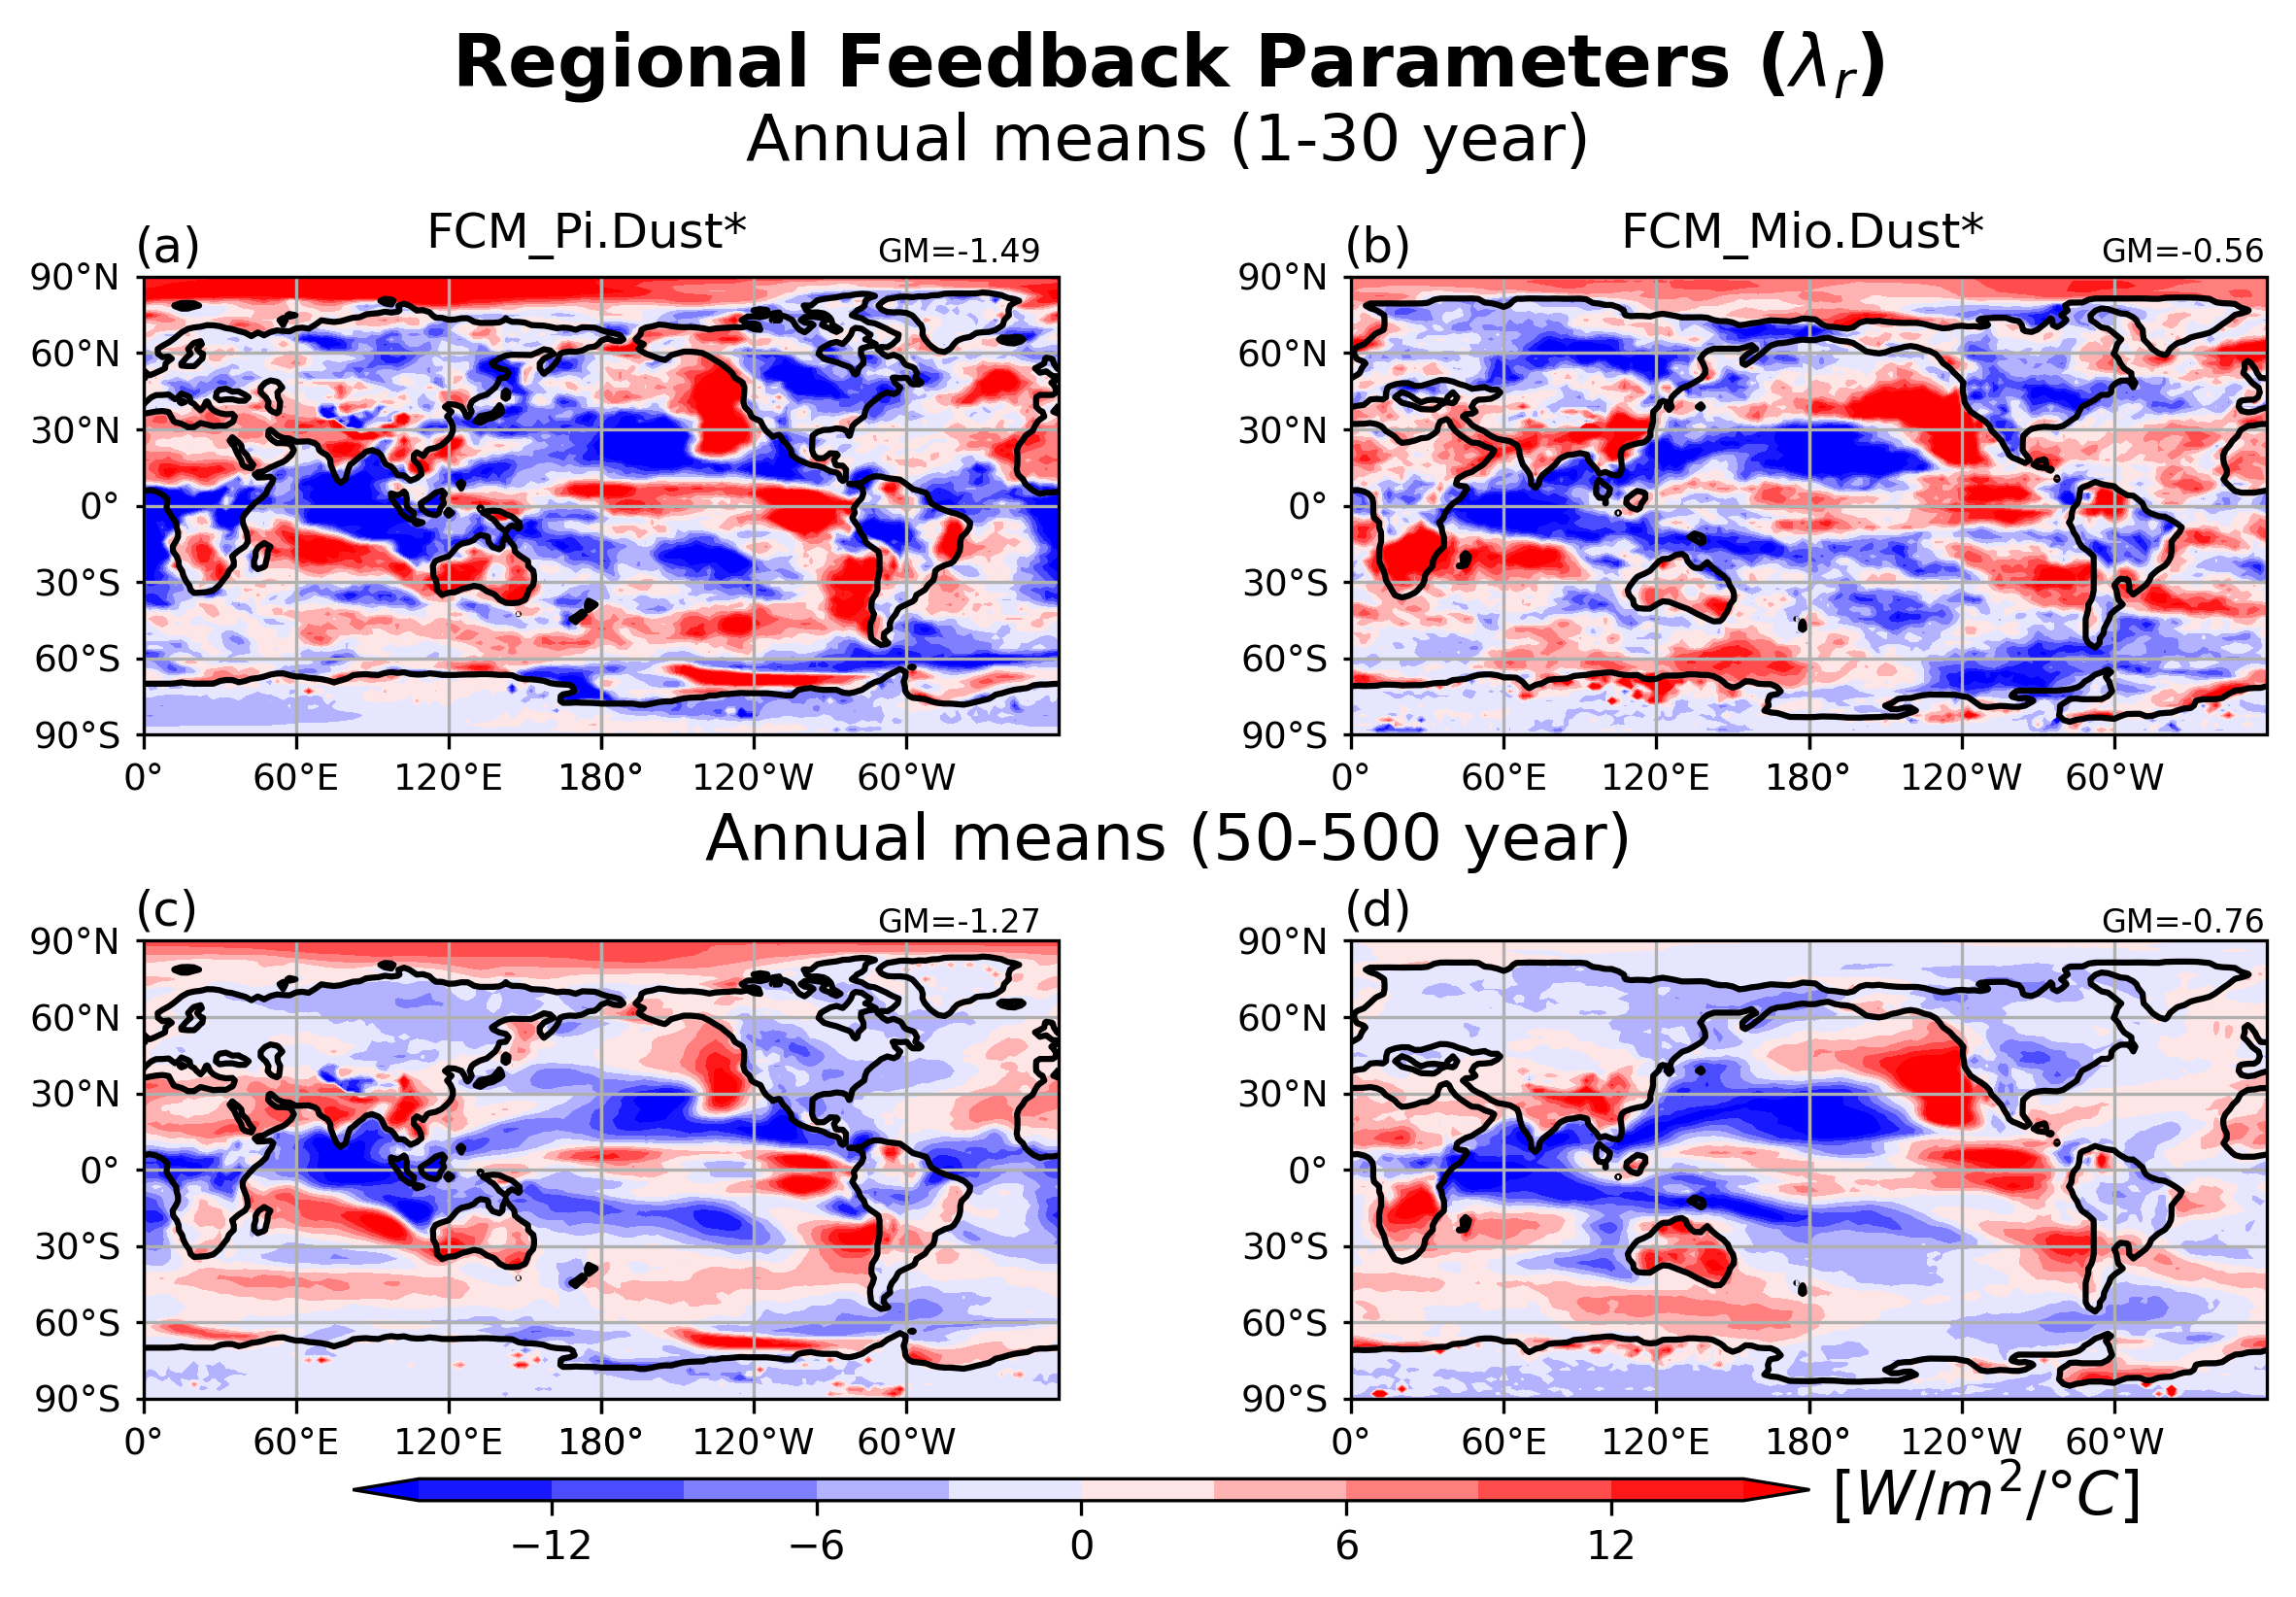

In [11]:
# --- plot ---

# Define the figure and each axis for the 2 rows and 2 columns
fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
                        figsize=(10,5), dpi=300)
    
# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.15, hspace=0.45) 
    
# axs is a 2 dimensional array of `GeoAxes`
# flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(pattern_lambda['pattern']):
        
    # Contour plot

    if i==0 or i==2:
        cs2=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-15, 15, 11),
                            transform = ccrs.PlateCarree(), cmap='bwr', extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)
    else:
        cs2=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-15, 15, 11),
                            transform = ccrs.PlateCarree(), cmap='bwr', extend='both')
        # Add coastines in Miocene Scenario
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=4)

    # Longitude labels
    axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()  
    axs[i].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
    axs[i].tick_params(axis='y', size=2)             # set xtick parameters
    for xlabel in axs[i].get_xticklabels():          # set xticks_label
        xlabel.set_fontsize(9)        

    # Latitude labels
    axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
    lat_formatter = cticker.LatitudeFormatter()
    axs[i].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
    axs[i].tick_params(axis='y', size=2)             # set ytick parameters
    for ylabel in axs[i].get_yticklabels():          # set yticks_label
        ylabel.set_fontsize(9)        
        
          
    # Add gridlines
    axs[i].gridlines(colors='white', linewidths=0.2, zorder=2)
        
# Add colorbar
cax2 = fig.add_axes([0.22, 0.04, 0.5, 0.015])    # set the [x0, y0, width, height] of the colorbar
CB2  = plt.colorbar(cs2, cax=cax2, orientation='horizontal')
    
# Add colobar's title
GM_Pi_first30 = 'GM='+str('{:03.2f}'.format(lambda_Pi_first30_mean.values))
GM_Mio_first30 = 'GM='+str('{:03.2f}'.format(lambda_Mio_first30_mean.values))
GM_Pi_after50 = 'GM='+str('{:03.2f}'.format(lambda_Pi_after50_mean.values))
GM_Mio_after50 = 'GM='+str('{:03.2f}'.format(lambda_Mio_after50_mean.values))

plt.figtext(0.78,0.03,'[$W/m^2/°C$]',ha='center',fontsize=15)
plt.figtext(0.145,0.89,'(a)',fontsize=12)
plt.figtext(0.56,0.89,'(b)',fontsize=12)
plt.figtext(0.245,0.9,'FCM_Pi.Dust*',fontsize=12)
plt.figtext(0.655,0.9,'FCM_Mio.Dust*',fontsize=12)
plt.figtext(0.4,0.89,GM_Pi_first30,fontsize=8)
plt.figtext(0.82,0.89,GM_Mio_first30,fontsize=8)
plt.figtext(0.145,0.435,'(c)',fontsize=12)
plt.figtext(0.56,0.435,'(d)',fontsize=12)
plt.figtext(0.4,0.43,GM_Pi_after50,fontsize=8)
plt.figtext(0.82,0.43,GM_Mio_after50,fontsize=8)

# Add title
plt.suptitle('Regional Feedback Parameters ($\lambda_r$)', y=1.05, fontsize=18, weight='bold')
plt.figtext(0.5,0.96,'Annual means (1-30 year)',ha='center',fontsize=16)
plt.figtext(0.5,0.48,'Annual means (50-500 year)',ha='center',fontsize=16)
# fig.savefig('plot_TS.png')
;

''

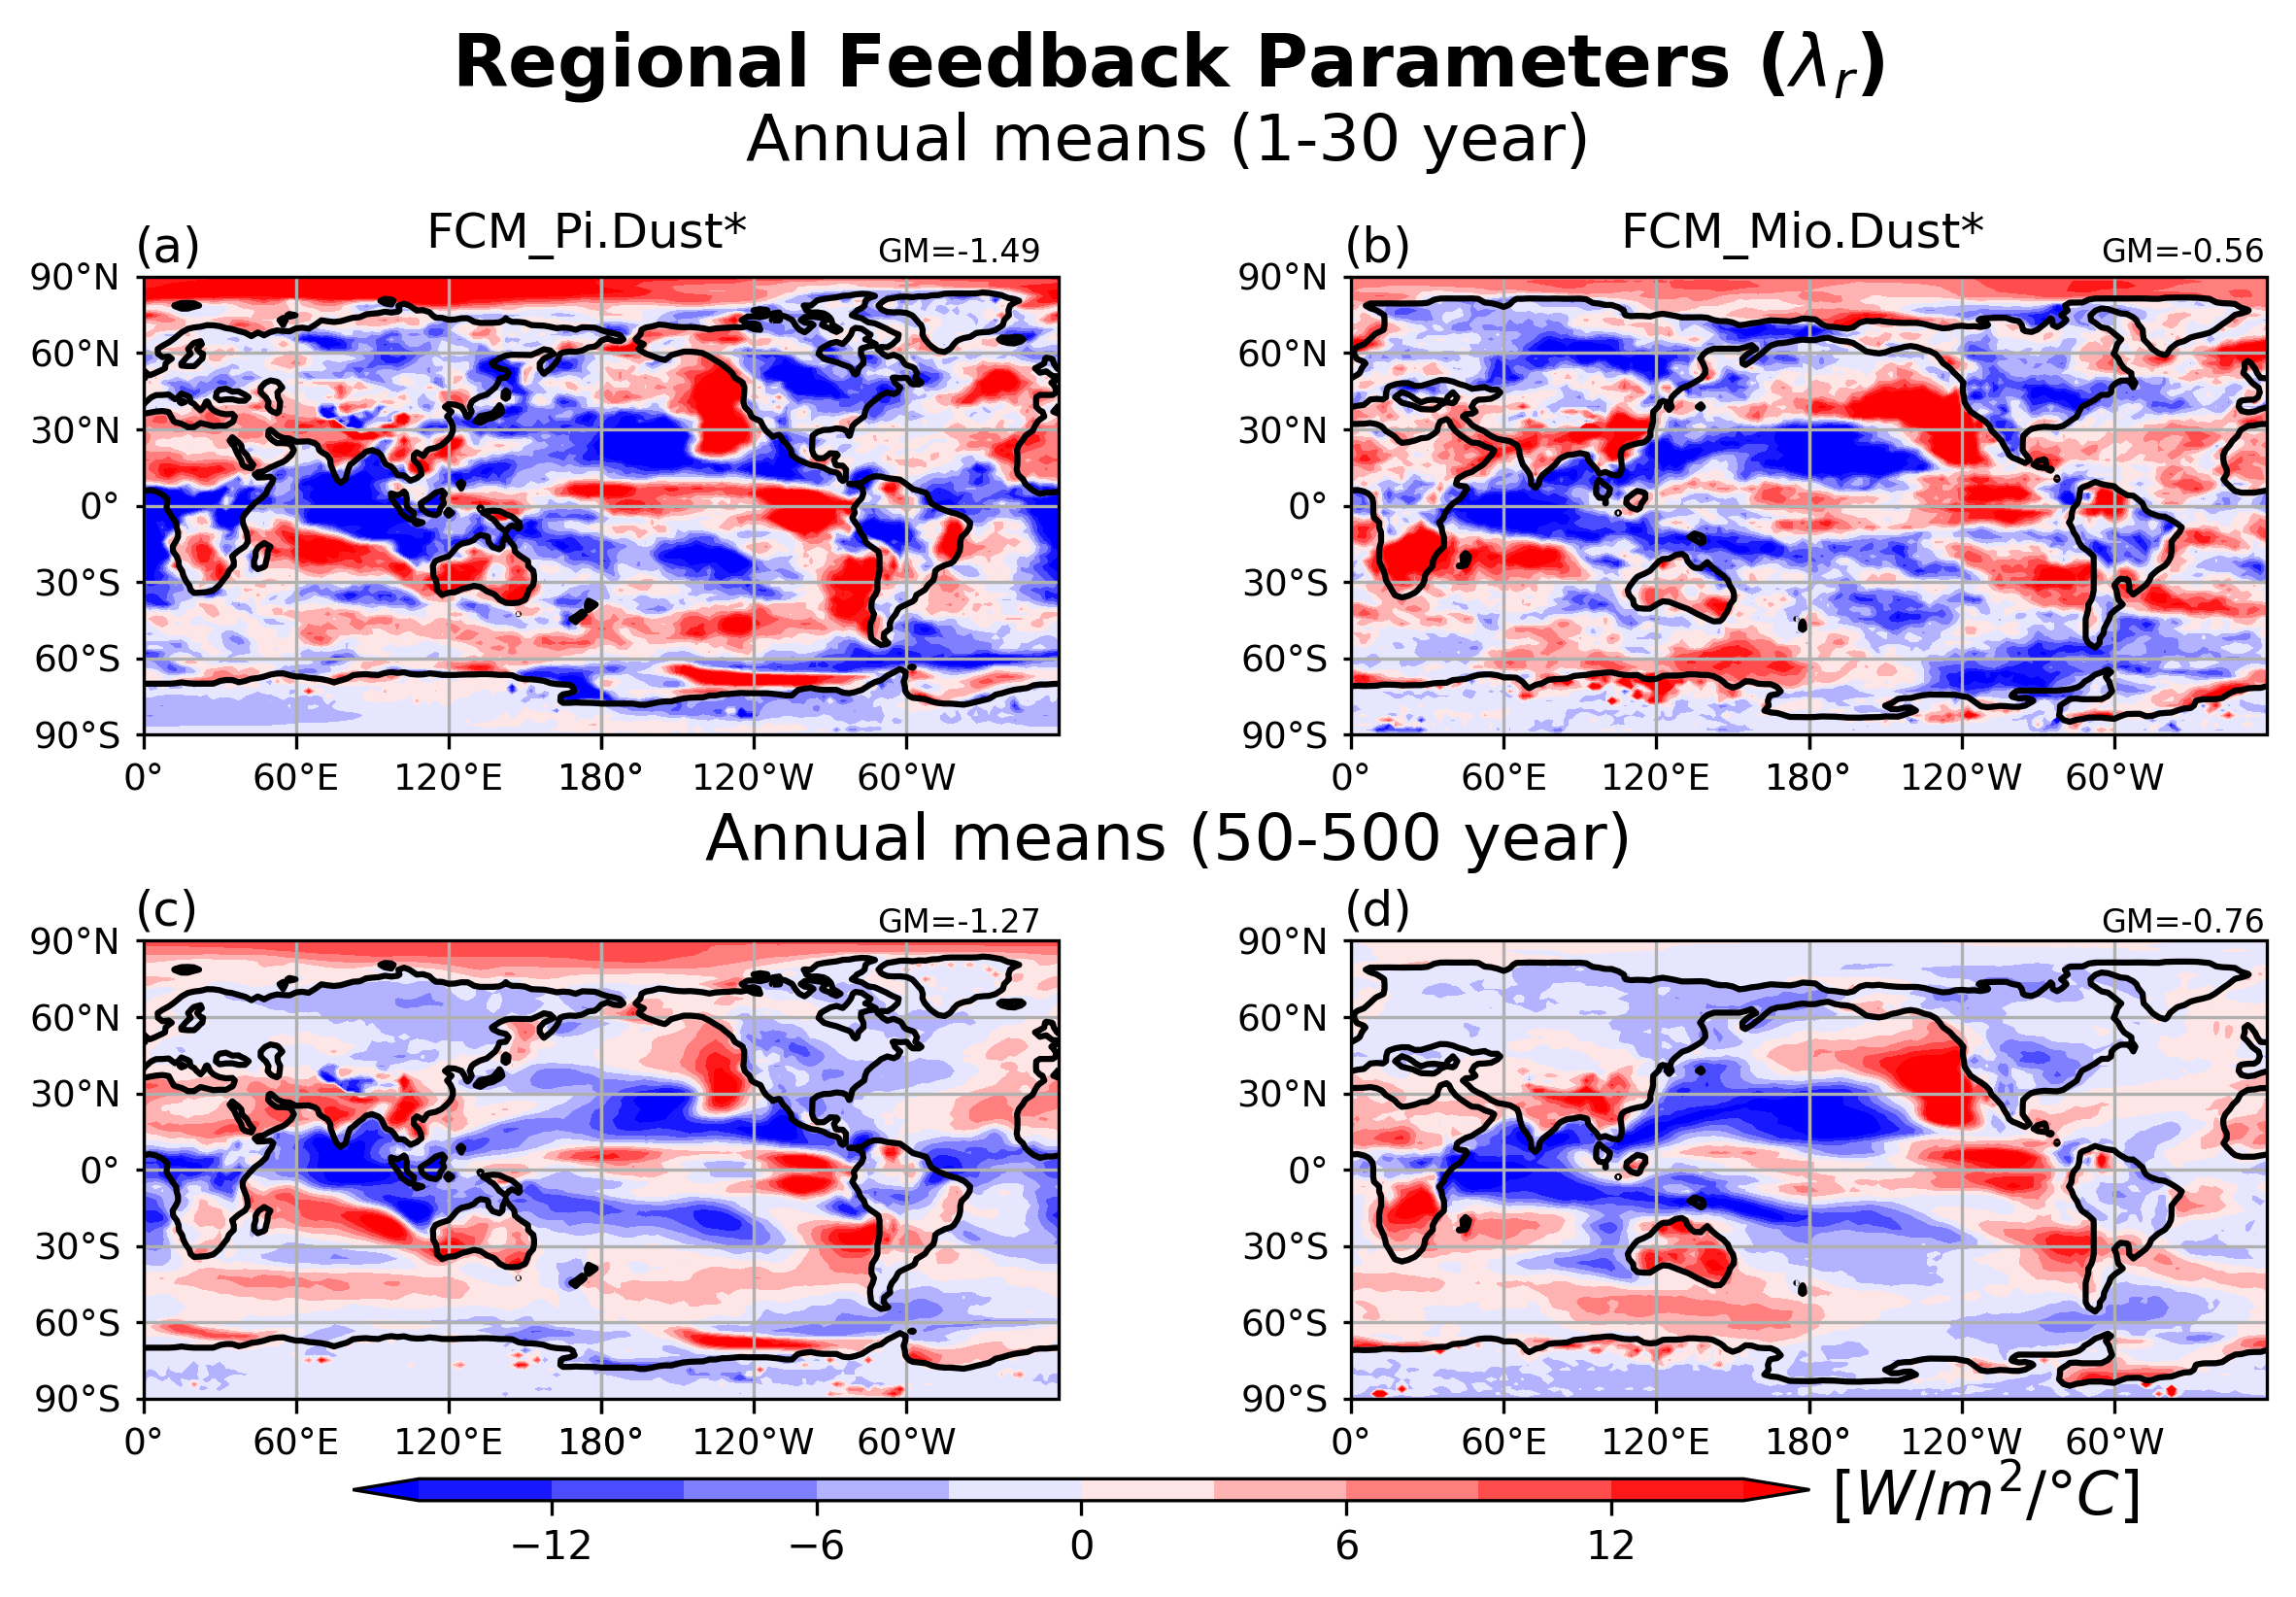

In [30]:
# --- plot ---

# Define the figure and each axis for the 4 rows and 3 columns
fig, axs = plt.subplots(nrows=2,ncols=2,
                        subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)},
                        figsize=(10,5), dpi=300)
    
# Set Width / Height padding between subplots, expressed as a fraction of the subplot width
fig.subplots_adjust(wspace=0.15, hspace=0.45) 
    
# axs is a 2 dimensional array of `GeoAxes`
# flatten it into a 1-D array
axs=axs.flatten()
    
# Loop over all of the months and plot
for i,m in enumerate(pattern_lambda['time']):
        
    # Contour plot
    # Add coastines in Miocene Scenario
    if i==0 or i==2:
        cs2=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-15, 15, 11),
                            transform = ccrs.PlateCarree(), cmap='bwr', extend='both')
        axs[i].contour(lons, lat, mask_Pi, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=3)
    else:
        cs2=axs[i].contourf(lons, lat, data[i,:,:], levels = np.linspace(-15, 15, 11),
                            transform = ccrs.PlateCarree(), cmap='bwr', extend='both')
        axs[i].contour(lons, lat, mask_Mio, [0.5,1.5],
                       transform = ccrs.PlateCarree(), colors='k', linewidths=1.5, zorder=4)

    # Longitude labels
    axs[i].set_xticks(np.arange(-180,181,60), crs=ccrs.PlateCarree())
    lon_formatter = cticker.LongitudeFormatter()  
    axs[i].xaxis.set_major_formatter(lon_formatter)  # set the format of xticks_label
    axs[i].tick_params(axis='y', size=2)             # set xtick parameters
    for xlabel in axs[i].get_xticklabels():          # set xticks_label
        xlabel.set_fontsize(9)        

    # Latitude labels
    axs[i].set_yticks(np.arange(-90,91,30), crs=ccrs.PlateCarree())
    lat_formatter = cticker.LatitudeFormatter()
    axs[i].yaxis.set_major_formatter(lat_formatter)  # set the format of yticks_label
    axs[i].tick_params(axis='y', size=2)             # set ytick parameters
    for ylabel in axs[i].get_yticklabels():          # set yticks_label
        ylabel.set_fontsize(9)        
        
        
    # Title each subplot with the name of the month
    # axs[i].set_title(title[i])
          
    # Add gridlines
    axs[i].gridlines(colors='white', linewidths=0.2, zorder=2)
        
# Add colorbar
cax2 = fig.add_axes([0.22, 0.04, 0.5, 0.015])    # set the [x0, y0, width, height] of the colorbar
CB2  = plt.colorbar(cs2, cax=cax2, orientation='horizontal')
    
# Add colobar's title
GM_PP_f = 'GM='+str('{:03.2f}'.format(lambda_PP_map_f_mean.values))
GM_MM_f = 'GM='+str('{:03.2f}'.format(lambda_MM_map_f_mean.values))
GM_PP_l = 'GM='+str('{:03.2f}'.format(lambda_PP_map_l_mean.values))
GM_MM_l = 'GM='+str('{:03.2f}'.format(lambda_MM_map_l_mean.values))

plt.figtext(0.78,0.03,'[$W/m^2/°C$]',ha='center',fontsize=15)
# plt.figtext(0.5,0.929,'From Annual means (50-500 year)',ha='center',fontsize=15)
# plt.figtext(0.155,0.89,'(c)',fontsize=12)
# plt.figtext(0.555,0.89,'(d)',fontsize=12)
# plt.figtext(0.4,0.89,GM_PP,fontsize=9)
# plt.figtext(0.8,0.89,GM_MM,fontsize=9)
# plt.figtext(0.5,0.72,'From bins of Decadal means (50-500 year)',ha='center',fontsize=15)
plt.figtext(0.145,0.89,'(a)',fontsize=12)
plt.figtext(0.56,0.89,'(b)',fontsize=12)
plt.figtext(0.245,0.9,'FCM_Pi.Dust*',fontsize=12)
plt.figtext(0.655,0.9,'FCM_Mio.Dust*',fontsize=12)
plt.figtext(0.4,0.89,GM_PP_f,fontsize=8)
plt.figtext(0.82,0.89,GM_MM_f,fontsize=8)
plt.figtext(0.145,0.435,'(c)',fontsize=12)
plt.figtext(0.56,0.435,'(d)',fontsize=12)
plt.figtext(0.4,0.43,GM_PP_l,fontsize=8)
plt.figtext(0.82,0.43,GM_MM_l,fontsize=8)

# Add title
plt.suptitle('Regional Feedback Parameters ($\lambda_r$)', y=1.05, fontsize=18, weight='bold')
plt.figtext(0.5,0.96,'Annual means (1-30 year)',ha='center',fontsize=16)
plt.figtext(0.5,0.48,'Annual means (50-500 year)',ha='center',fontsize=16)
# fig.savefig('plot_TS.png')
;